In [1]:
from torchvision import models
import torch.nn as nn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import json
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
PROJECT_ROOT = get_project_root()
CLASSES_DIR = PROJECT_ROOT / "Classes"
DATA_DIR = PROJECT_ROOT / "Data"

device = get_device()

Using device: cuda


In [4]:
SPLIT_DIR = DATA_DIR / "splits"

train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

### Baseline Model - ResNet18

#### Build Data Loaders

In [5]:
train_tfms_mild = get_train_tfms_mild()
train_tfms_strong = get_train_tfms_strong()
val_tfms = get_val_tfms()

In [6]:
CLASSES = sorted(train["class"].unique().tolist())

In [7]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x7f5a08095010>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x7f5a0aa87f10>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x7f5a0aa2e350>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x7f56ffd84050>}

In [8]:
train_loader = loaders["train_loader_mild"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [9]:
criterion = nn.CrossEntropyLoss()

#### Training and Validation

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [12]:
def run_one_epoch(model, loader, criterion, optimizer, device, scaler=None, is_train=False, return_preds=False):
    running_loss = 0.0
    running_correct = 0
    total = 0

    d = device if isinstance(device, torch.device) else torch.device(device)
    use_amp = (d.type == "cuda") and (scaler is not None)

    all_preds, all_labels = [], []

    if is_train:
        model.train()
        for img, labels in loader:
            img = img.to(d, non_blocking=True)
            labels = labels.to(d, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    outputs = model(img)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(img)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(1)
            running_loss += loss.item() * img.size(0)
            running_correct += (preds == labels).sum().item()
            total += img.size(0)

            if return_preds:
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())
    else:
        model.eval()
        with torch.no_grad():
            for img, labels in loader:
                img = img.to(d, non_blocking=True)
                labels = labels.to(d, non_blocking=True)

                outputs = model(img)
                loss = criterion(outputs, labels)

                preds = outputs.argmax(1)
                running_loss += loss.item() * img.size(0)
                running_correct += (preds == labels).sum().item()
                total += img.size(0)

                if return_preds:
                    all_preds.append(preds.cpu())
                    all_labels.append(labels.cpu())

    total_loss = running_loss / max(total, 1)
    total_acc  = running_correct / max(total, 1)

    if return_preds:
        return total_loss, total_acc, total, torch.cat(all_labels), torch.cat(all_preds)
    else:
        return total_loss, total_acc, total, None, None

In [11]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet18_best.pth"
BEST_MODEL_PATH

PosixPath('/home/xuy001/teams/z8/data.science/04_Model/best_models/resnet18_best.pth')

In [13]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=3):
    best_val_acc = -float("inf")
    bad_epochs = 0

    d = device if isinstance(device, torch.device) else torch.device(device)
    use_amp = (d.type == "cuda")
    print("device = ", d)
    print("use_amp = ", use_amp)

    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None

    for epoch in range(num_epochs):
        print(f"\n>>> Epoch {epoch + 1} start", flush=True)

        train_loss, train_acc, _, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, d, scaler=scaler, is_train=True, return_preds=False
        )
        val_loss, val_acc, _, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, d, is_train=False, return_preds=False
        )

        print(f"Epoch {epoch + 1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}.")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(">>> Saved best model (by val_acc)", flush=True)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered (val_acc).", flush=True)
                break

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=d))
    return model

In [33]:
train(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, device=device, patience=5)

device =  cuda
use_amp =  True

>>> Epoch 1 start
Epoch 1: train_loss=0.6360, train_acc=0.7258, val_loss=0.6020, val_acc=0.7379.
>>> Saved best model (by val_acc)

>>> Epoch 2 start
Epoch 2: train_loss=0.5133, train_acc=0.7849, val_loss=0.4924, val_acc=0.7875.
>>> Saved best model (by val_acc)

>>> Epoch 3 start
Epoch 3: train_loss=0.4653, train_acc=0.8098, val_loss=0.5429, val_acc=0.7829.

>>> Epoch 4 start
Epoch 4: train_loss=0.4229, train_acc=0.8252, val_loss=0.4623, val_acc=0.8113.
>>> Saved best model (by val_acc)

>>> Epoch 5 start
Epoch 5: train_loss=0.3856, train_acc=0.8433, val_loss=0.4442, val_acc=0.8200.
>>> Saved best model (by val_acc)

>>> Epoch 6 start
Epoch 6: train_loss=0.3571, train_acc=0.8564, val_loss=0.4257, val_acc=0.8279.
>>> Saved best model (by val_acc)

>>> Epoch 7 start
Epoch 7: train_loss=0.3263, train_acc=0.8709, val_loss=0.4512, val_acc=0.8182.

>>> Epoch 8 start
Epoch 8: train_loss=0.2964, train_acc=0.8832, val_loss=0.4299, val_acc=0.8356.
>>> Saved best 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)
state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Testing

In [15]:
test_loss, test_acc, test_total, test_labels, test_preds = run_one_epoch(
    model, test_loader, criterion, optimizer, device, is_train=False, return_preds=True
)

In [16]:
print("Test accuracy:", test_acc)

Test accuracy: 0.8324683412912601


In [17]:
cm = confusion_matrix(test_labels, test_preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n",
    classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

Confusion matrix:
 [[1259  242  104]
 [ 134 1340  132]
 [  69  126 1411]]

Classification report:
                       precision    recall  f1-score   support

conditionally_edible     0.8611    0.7844    0.8210      1605
              edible     0.7845    0.8344    0.8087      1606
               toxic     0.8567    0.8786    0.8675      1606

            accuracy                         0.8325      4817
           macro avg     0.8341    0.8325    0.8324      4817
        weighted avg     0.8341    0.8325    0.8324      4817



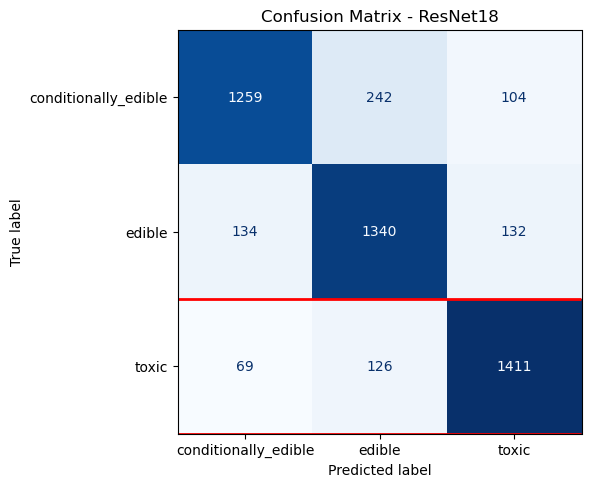

In [19]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - ResNet18")

# highlight toxic row
toxic_idx = CLASSES.index("toxic")
ax.hlines(toxic_idx - 0.5, -0.5, len(CLASSES)-0.5, colors="red", linewidth=2)
ax.hlines(toxic_idx + 0.5, -0.5, len(CLASSES)-0.5, colors="red", linewidth=2)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "Graphs" / "resnet18_confusion_matrix.png",
    dpi=300
)

plt.show()

#### Sample Toxic Classes Misclassified to Other Classes

In [21]:
test_df = test_loader.dataset.df
test_df['pred'] = [CLASSES[i] for i in test_preds]
misclassified_toxic = test_df[(test_df['class'] == 'toxic') & (test_df['pred'] != 'toxic')]
misclassified_toxic.pred.value_counts(normalize=True)

pred
edible                  0.646154
conditionally_edible    0.353846
Name: proportion, dtype: float64

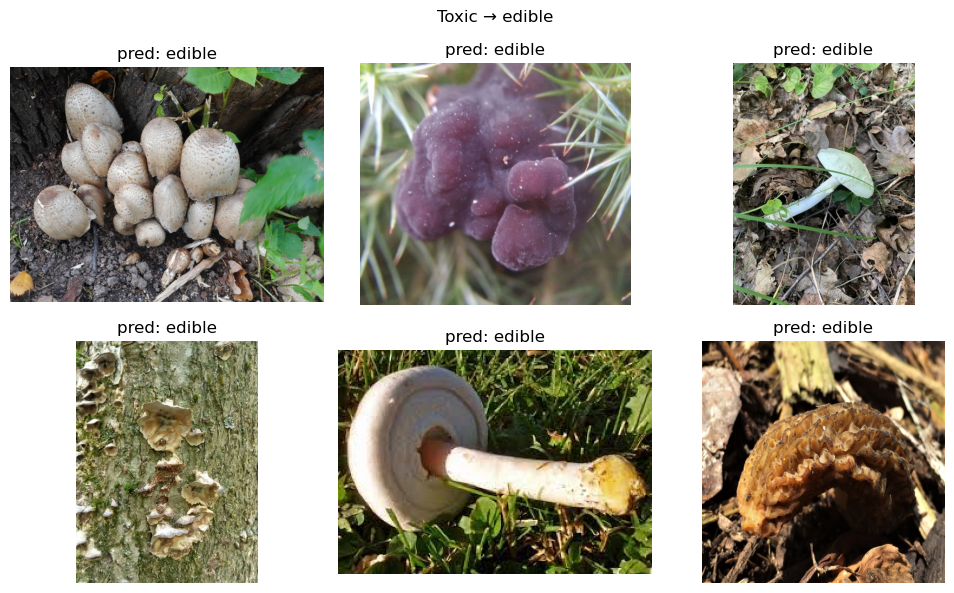

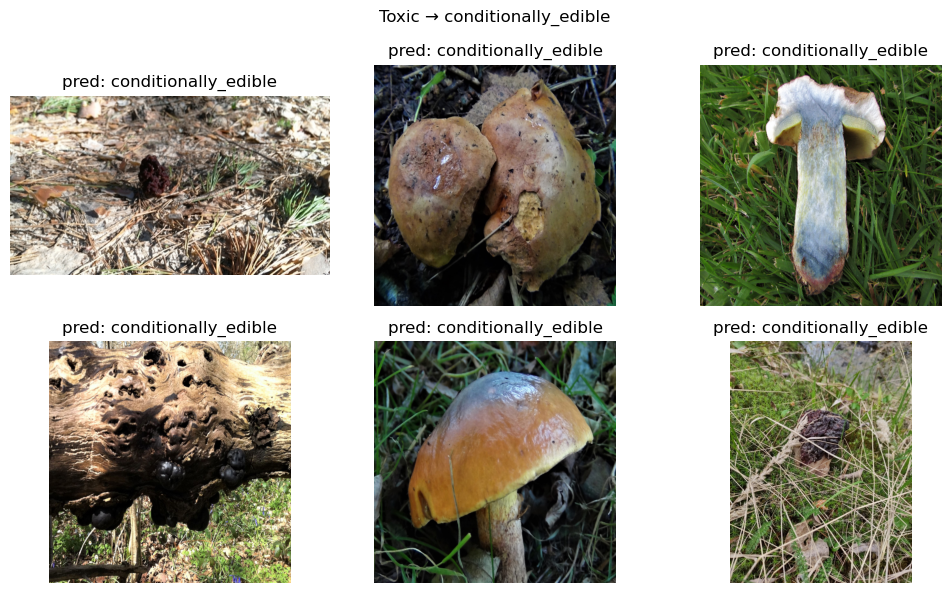

In [22]:
for wrong_pred in ['edible', 'conditionally_edible']:
    
    subset = misclassified_toxic[misclassified_toxic['pred'] == wrong_pred]
    sample = subset.sample(6, random_state=42)
    
    plt.figure(figsize=(10,6))
    
    for i, (_, row) in enumerate(sample.iterrows()):
        plt.subplot(2,3,i+1)
        img = Image.open(CLASSES_DIR / row['file_path'])
        plt.imshow(img)
        plt.title(f"pred: {wrong_pred}")
        plt.axis("off")
    
    plt.suptitle(f"Toxic → {wrong_pred}")
    plt.tight_layout()
    plt.show()